In [56]:
# =========================
# Step 1: Import Libraries
# =========================
import os
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from xgboost import XGBClassifier

import joblib

In [57]:
df = pd.read_csv("loan_risk_prediction_dataset.csv")

csv_file = [f for f in os.listdir() if f.endswith(".csv")][0]
df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
0   56  48353.0     31258.0        675.0               20  Female   
1   69  57462.0     23262.0        586.0                6    Male   
2   46  44219.0     26530.0        781.0               26    Male   
3   32  56307.0     11531.0        549.0               11    Male   
4   60  37034.0     27871.0        500.0               19  Female   

     Education           City EmploymentType  LoanApproved  
0  High School        Houston     Unemployed             1  
1  High School  San Francisco  Self-Employed             1  
2          PhD        Houston  Self-Employed             0  
3          NaN       New York     Unemployed             1  
4  High School        Chicago     Unemployed             1  


In [58]:
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [59]:
df[2287:2290]

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
2287,51,41673.0,9735.0,393.0,20,Male,High School,Chicago,Salaried,1
2288,42,43051.0,16638.0,528.0,13,Female,PhD,San Francisco,Salaried,1
2289,67,61539.0,36496.0,549.0,9,Male,PhD,New York,Unemployed,1


In [60]:
# =========================
# Step 5: Explore Dataset
# =========================
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape of dataset: (5000, 10)

Columns:
 ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB
None

Missing Values:
Age                  0
Income             196
LoanAmount           0
CreditSc

In [61]:
# Enable IterativeImputer (important)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

In [62]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

Numeric Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'LoanApproved']
Categorical Columns: ['Gender', 'Education', 'City', 'EmploymentType']


In [63]:
target_col = "LoanApproved"

if target_col in numeric_cols:
    numeric_cols.remove(target_col)

if target_col in categorical_cols:
    categorical_cols.remove(target_col)

In [64]:
# Iterative Imputer for numeric columns
iter_imputer = IterativeImputer(random_state=42)

df[numeric_cols] = iter_imputer.fit_transform(df[numeric_cols])

In [65]:
# Simple Imputer for categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [66]:
print("Missing Values After Imputation:")
print(df.isnull().sum())

Missing Values After Imputation:
Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64


In [67]:
# =========================
# Step 9: Encode Target Variable
# =========================
print("Unique values in target before encoding:", df[target_col].unique())

if df[target_col].dtype == "object":
    le_target = LabelEncoder()
    df[target_col] = le_target.fit_transform(df[target_col])

print("Unique values in target after encoding:", df[target_col].unique())

Unique values in target before encoding: [1 0]
Unique values in target after encoding: [1 0]


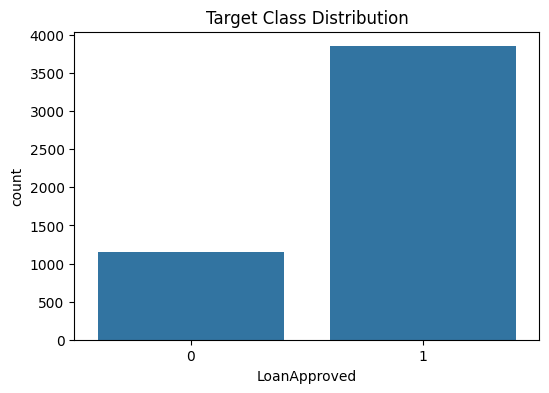

LoanApproved
1    3849
0    1151
Name: count, dtype: int64


In [68]:
# =========================
# Step 10: Target Distribution
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x=df[target_col])
plt.title("Target Class Distribution")
plt.show()

print(df[target_col].value_counts())

In [69]:
# =========================
# Step 11: Feature / Target Split
# =========================
X = df.drop(columns=[target_col])
y = df[target_col]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5000, 9)
Target shape: (5000,)


In [70]:
# =========================
# Step 13: One-Hot Encoding
# =========================
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", X.shape)
X.head()

Shape after encoding: (5000, 14)


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender_Male,Education_High School,Education_Masters,Education_PhD,City_Houston,City_New York,City_San Francisco,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56.0,48353.0,31258.0,675.0,20.0,False,True,False,False,True,False,False,False,True
1,69.0,57462.0,23262.0,586.0,6.0,True,True,False,False,False,False,True,True,False
2,46.0,44219.0,26530.0,781.0,26.0,True,False,False,True,True,False,False,True,False
3,32.0,56307.0,11531.0,549.0,11.0,True,False,False,False,False,True,False,False,True
4,60.0,37034.0,27871.0,500.0,19.0,False,True,False,False,False,False,False,False,True


In [71]:
# =========================
# Step 14: Train Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (4000, 14)
X_test : (1000, 14)


In [72]:
# =========================
# Step 15: Feature Scaling
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
# =========================
# Step 17: Train XGBoost Model
# =========================
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)
print("Model training completed!")

Model training completed!


In [74]:
# =========================
# Step 18: Predictions
# =========================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [75]:
# =========================
# Step 19: Evaluation Metrics
# =========================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC AUC  :", round(roc_auc, 4))

Accuracy : 0.96
Precision: 0.962
Recall   : 0.987
F1 Score : 0.9744
ROC AUC  : 0.9431


In [76]:
# =========================
# Step 20: Classification Report
# =========================
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91       230
           1       0.96      0.99      0.97       770

    accuracy                           0.96      1000
   macro avg       0.96      0.93      0.94      1000
weighted avg       0.96      0.96      0.96      1000



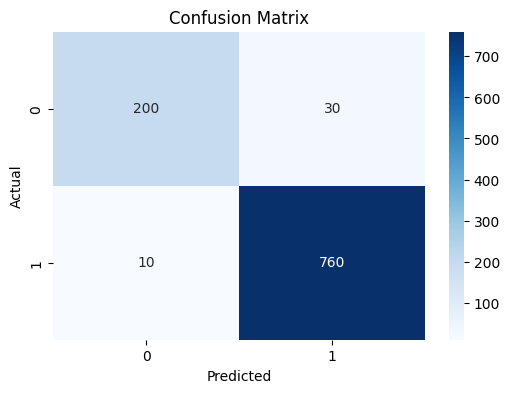

In [77]:
# =========================
# Step 21: Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

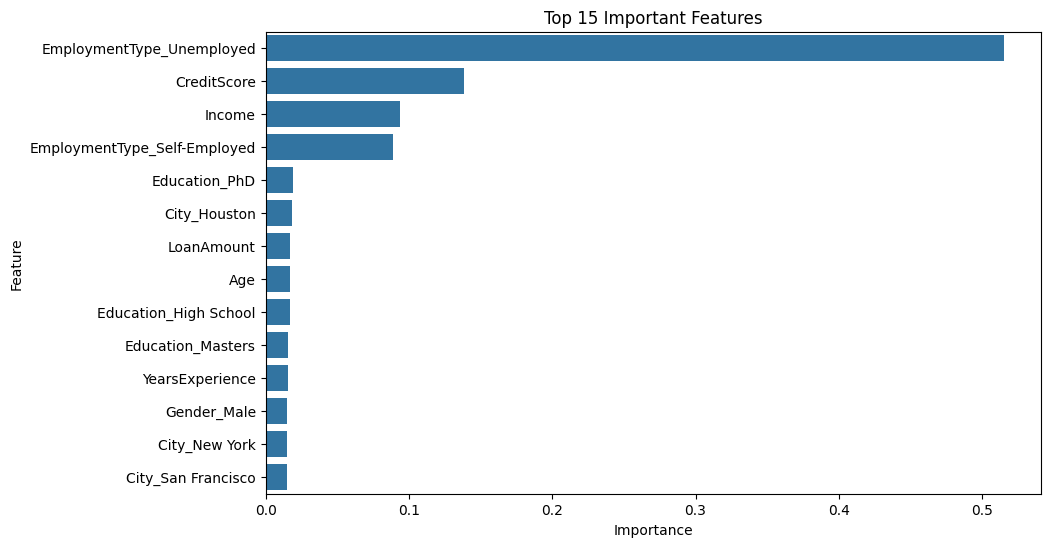

,Feature,Importance
13,EmploymentType_Unemployed,0.515096
3,CreditScore,0.138326
1,Income,0.093467
12,EmploymentType_Self-Employed,0.089097
8,Education_PhD,0.018959
9,City_Houston,0.018183
2,LoanAmount,0.017125
0,Age,0.017036
6,Education_High School,0.016967
7,Education_Masters,0.015647


In [78]:
# =========================
# Step 22: Feature Importance
# =========================
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title("Top 15 Important Features")
plt.show()

importance_df.head(15)

In [79]:
# =========================
# Step 24: Save Model & Objects
# =========================
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Saved files:")
print("- model.pkl")
print("- scaler.pkl")
print("- feature_columns.pkl")

Saved files:
- model.pkl
- scaler.pkl
- feature_columns.pkl
